/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell M31 is marked as a date but the serial value 6440726.918349998 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell N31 is marked as a date but the serial value 15978420 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)
/tmp/ipython-input-3978822889.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(liste_hotels))


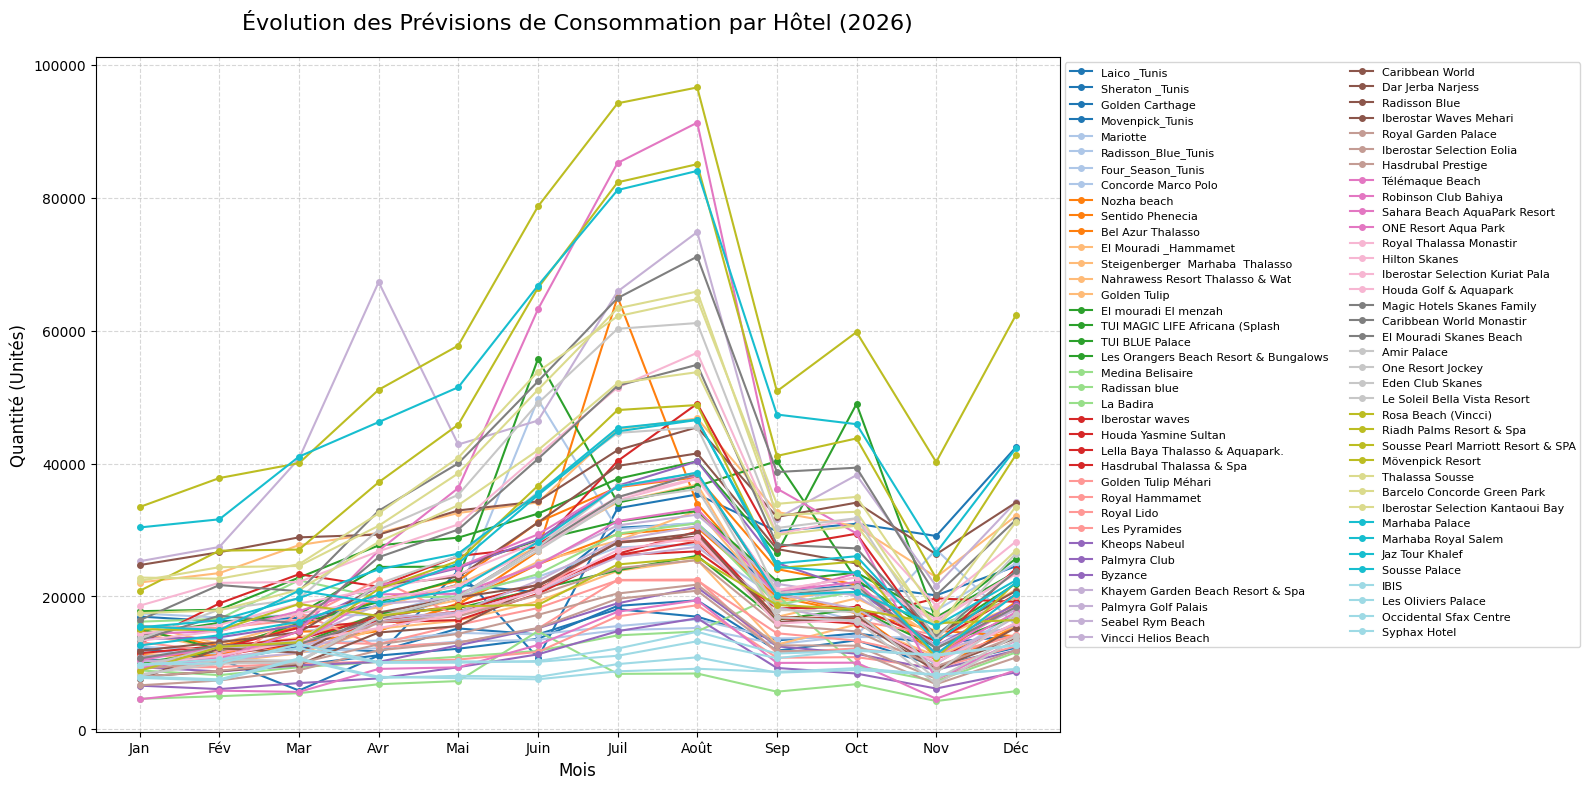

/tmp/ipython-input-3978822889.py:121: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: f"color: {'#16a34a' if x > 0 else '#dc2626'}", subset=["Variation %"])\
/tmp/ipython-input-3978822889.py:122: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: f"color: #16a34a; font-weight: bold;" if x > 95 else "", subset=["Précision %"])\
/tmp/ipython-input-3978822889.py:121: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: f"color: {'#16a34a' if x > 0 else '#dc2626'}", subset=["Variation %"])\
/tmp/ipython-input-3978822889.py:122: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: f"color: #16a34a; font-weight: bold;" if x > 95 else "", subset=["Précision %"])\


Hôtel,Région,Total 2025,Total 2026,Variation %,MAE,R2,Précision %
Mövenpick Resort,sousse,"702,795","702,946",+0.0%,65.1,0.986,96.6%
Jaz Tour Khalef,sousse,"595,226","594,951",-0.0%,53.1,0.989,96.7%
Riadh Palms Resort & Spa,sousse,"540,162","540,635",+0.1%,50.8,0.990,96.6%
Khayem Garden Beach Resort & Spa,Nabeul,"494,841","516,666",+4.4%,50.9,0.987,96.4%
Caribbean World Monastir,Monastir,"450,071","450,111",+0.0%,39.7,0.991,96.8%
Barcelo Concorde Green Park,sousse,"445,214","444,489",-0.2%,37.7,0.989,96.9%
Thalassa Sousse,sousse,"432,737","432,045",-0.2%,36.9,0.991,96.9%
Sahara Beach AquaPark Resort,Monastir,"424,386","424,323",-0.0%,28.2,0.998,97.6%
Radisson Blue,Djerba,"390,397","390,931",+0.1%,22.7,0.984,97.9%
Le Soleil Bella Vista Resort,Monastir,"388,875","389,220",+0.1%,34.0,0.992,96.8%


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML, display_html
import joblib
import os

# ==========================================
# 1. CONFIGURATION ET CHARGEMENT
# ==========================================
FILE_PATH = '/content/Liste_HHotels.xlsx'
COEFF_LITRE = 0.057
OUTPUT_DIR = 'modeles_ia_hotels'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_excel(FILE_PATH)
df.columns = df.columns.str.strip()
df['Hotel'] = df['Hotel'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Consommation Œuf'] = pd.to_numeric(df['Consommation Œuf'], errors='coerce')
df.dropna(subset=['Date', 'Consommation Œuf'], inplace=True)

def create_features(df_feat):
    df_feat = df_feat.copy()
    df_feat['month'] = df_feat['ds'].dt.month
    df_feat['day_of_week'] = df_feat['ds'].dt.dayofweek
    df_feat['day_of_year'] = df_feat['ds'].dt.dayofyear
    df_feat['quarter'] = df_feat['ds'].dt.quarter
    df_feat['is_weekend'] = df_feat['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    return df_feat

# ========================================== # 2. CALCULS IA ET GÉNÉRATION DES DONNÉES
# ==========================================
liste_hotels = df['Hotel'].unique()
features_cols = ['month', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend']
stats_data = []
mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

# Initialisation de la figure pour les courbes
plt.figure(figsize=(16, 8))
colors = plt.cm.get_cmap('tab20', len(liste_hotels))

for idx, hotel in enumerate(liste_hotels):
    df_h = df[df['Hotel'] == hotel].copy()
    df_daily = df_h.groupby('Date')['Consommation Œuf'].sum().reset_index()
    if len(df_daily) < 10: continue

    df_train_set = df_daily.rename(columns={'Date': 'ds', 'Consommation Œuf': 'y'})
    df_f = create_features(df_train_set)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_f[features_cols])

    model = XGBRegressor(n_estimators=800, learning_rate=0.02, max_depth=4, random_state=42)
    model.fit(X_scaled, df_f['y'])

    # Prévision 2026
    future_dates = pd.date_range(start='2026-01-01', end='2026-12-31', freq='D')
    df_future = create_features(pd.DataFrame({'ds': future_dates}))
    X_fut_scaled = scaler.transform(df_future[features_cols])
    df_future['yhat'] = model.predict(X_fut_scaled)

    # --- BLOC GRAPHIQUE ---
    conso_mensuelle = df_future.groupby(df_future['ds'].dt.month)['yhat'].sum().reindex(range(1, 13), fill_value=0)
    plt.plot(range(1, 13), conso_mensuelle, '-o', color=colors(idx), linewidth=1.5, markersize=4, label=hotel)
    # ----------------------

    preds_train = model.predict(X_scaled)
    mae_val = mean_absolute_error(df_f['y'], preds_train)
    r2_val = r2_score(df_f['y'], preds_train)

    t_2025 = df_train_set[df_train_set['ds'].dt.year == 2025]['y'].sum()
    t_2026 = df_future['yhat'].sum()
    variation = ((t_2026 - t_2025) / t_2025 * 100) if t_2025 > 0 else 0
    region = str(df_h['Région'].iloc[0]) if 'Région' in df_h.columns else 'Non définie'

    stats_data.append({
        "Hôtel": hotel,
        "Région": region if region != 'nan' else 'Non définie',
        "Total 2025": t_2025,
        "Total 2026": t_2026,
        "Variation %": variation,
        "MAE": mae_val,
        "R2": r2_val
    })

# Finalisation du graphique
plt.title("Évolution des Prévisions de Consommation par Hôtel (2026)", fontsize=16, pad=20)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Quantité (Unités)", fontsize=12)
plt.xticks(range(1, 13), mois_labels)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='8', ncol=2)
plt.tight_layout()
plt.show()

# ========================================== # 3. RENDU FINAL : PROTECTION TOTALE CONTRE LES COUPURES
# ==========================================

# 1. Préparation des données
df_oeufs = pd.DataFrame(stats_data).sort_values(by="Total 2026", ascending=False)
df_oeufs['Précision %'] = df_oeufs.apply(
    lambda x: max(0, 100 - (x['MAE'] / (x['Total 2026'] / 365) * 100)), axis=1
)

df_litres = df_oeufs.copy()
for col in ["Total 2025", "Total 2026", "MAE"]:
    df_litres[col] = df_litres[col] * COEFF_LITRE

# 2. Fonction de style avec contrôle strict des largeurs
def style_ranking_final(df_target, title):
    return df_target.style.hide(axis='index')\
        .set_caption(f"<div style='background:#1e293b; color:white; padding:10px; font-weight:bold; font-size:14px; border-radius:8px 8px 0 0;'>{title}</div>")\
        .format({
            "Total 2025": "{:,.0f}", "Total 2026": "{:,.0f}",
            "Variation %": lambda x: f"<b>{x:+.1f}%</b>",
            "Précision %": "{:.1f}%", "R2": "{:.3f}", "MAE": "{:.1f}"
        })\
        .applymap(lambda x: f"color: {'#16a34a' if x > 0 else '#dc2626'}", subset=["Variation %"])\
        .applymap(lambda x: f"color: #16a34a; font-weight: bold;" if x > 95 else "", subset=["Précision %"])\
        .set_table_styles([
            # Table layout FIXED pour garantir que tout rentre
            {'selector': 'table', 'props': [('width', '100%'), ('table-layout', 'fixed'), ('border-collapse', 'collapse')]},
            {'selector': 'th', 'props': [('background', '#f8fafc'), ('color', '#64748b'), ('padding', '8px 4px'), ('font-size', '11px'), ('border-bottom', '2px solid #e2e8f0'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '4px 6px'), ('border', 'none'), ('text-align', 'center'), ('font-size', '11px'), ('overflow', 'hidden'), ('text-overflow', 'ellipsis'), ('white-space', 'nowrap')]},

            # Ajustement des largeurs de colonnes (Total = 100%)
            {'selector': 'th.col0', 'props': [('width', '25%'), ('text-align', 'left'), ('padding-left', '10px')]},
            {'selector': 'th.col1', 'props': [('width', '12%'), ('text-align', 'left')]},
            {'selector': 'th.col2', 'props': [('width', '13%')]},
            {'selector': 'th.col3', 'props': [('width', '13%')]},
            {'selector': 'th.col4', 'props': [('width', '11%')]},
            {'selector': 'th.col5', 'props': [('width', '8%')]},
            {'selector': 'th.col6', 'props': [('width', '8%')]},
            {'selector': 'th.col7', 'props': [('width', '10%')]},

            # Styles spécifiques aux cellules de texte
            {'selector': 'td.col0', 'props': [('text-align', 'left'), ('font-weight', 'bold'), ('color', '#0f172a')]},
            {'selector': 'td.col1', 'props': [('text-align', 'left'), ('color', '#64748b')]}
        ])

# 3. Génération du HTML
html_oeufs = style_ranking_final(df_oeufs, "CLASSEMENT UNITÉS (ŒUFS)").to_html()
html_litres = style_ranking_final(df_litres, "CLASSEMENT VOLUMES (LITRES)").to_html()

# 4. Affichage avec conteneur élargi
display(HTML(f"""
<div style="width: 100%; display: flex; flex-direction: column; align-items: center; font-family: sans-serif; margin-top: 10px;">
    <div style="display: flex; gap: 15px; justify-content: center; width: 99%; max-width: 1700px;">
        <div style="flex: 1; border: 1px solid #e2e8f0; border-radius: 10px; background: white; box-shadow: 0 4px 12px rgba(0,0,0,0.08); overflow: hidden;">
            {html_oeufs}
        </div>
        <div style="flex: 1; border: 1px solid #e2e8f0; border-radius: 10px; background: white; box-shadow: 0 4px 12px rgba(0,0,0,0.08); overflow: hidden;">
            {html_litres}
        </div>
    </div>
</div>
<br>
"""))
# ============================================================================
# BARRE KPI GLOBALE : INTÉGRATION VARIATION, MAE ET R2 MOYEN
# ============================================================================

# 1. Calculs consolidés
g_t25 = df_oeufs['Total 2025'].sum()
g_t26 = df_oeufs['Total 2026'].sum()
g_var = ((g_t26 - g_t25) / g_t25 * 100) if g_t25 > 0 else 0

# Moyennes des métriques de performance IA
g_mae = df_oeufs['MAE'].mean()
g_r2  = df_oeufs['R2'].mean()
g_prec = df_oeufs['Précision %'].mean()

# 2. Couleurs dynamiques
v_color = "#4ade80" if g_var >= 0 else "#f87171"

# 3. Rendu HTML (Format large pour inclure R2 et MAE)
html_kpi_global = f"""
<div style="background: #1e293b; color: white; padding: 20px; border-radius: 12px 12px 0 0; font-family: sans-serif; border-bottom: 2px solid #334155;">
    <div style="display: flex; justify-content: space-between; align-items: center; text-align: center; gap: 10px;">

        <div style="flex: 1.5; border-right: 1px solid #334155;">
            <div style="color: #94a3b8; font-size: 10px; text-transform: uppercase; margin-bottom: 5px;">Total 2025</div>
            <div style="font-size: 20px; font-weight: bold;">{g_t25:,.0f}</div>
        </div>

        <div style="flex: 1.5; border-right: 1px solid #334155;">
            <div style="color: #94a3b8; font-size: 10px; text-transform: uppercase; margin-bottom: 5px;">Prédit 2026</div>
            <div style="font-size: 20px; font-weight: bold;">{g_t26:,.0f}</div>
        </div>

        <div style="flex: 1; border-right: 1px solid #334155;">
            <div style="color: #94a3b8; font-size: 10px; text-transform: uppercase; margin-bottom: 5px;">Variation</div>
            <div style="font-size: 20px; font-weight: bold; color: {v_color};">{g_var:+.1f}%</div>
        </div>

        <div style="flex: 1; border-right: 1px solid #334155;">
            <div style="color: #94a3b8; font-size: 10px; text-transform: uppercase; margin-bottom: 5px;">MAE Moy.</div>
            <div style="font-size: 18px; font-weight: bold; color: #facc15;">{g_mae:.1f}</div>
        </div>

        <div style="flex: 1; border-right: 1px solid #334155;">
            <div style="color: #94a3b8; font-size: 10px; text-transform: uppercase; margin-bottom: 5px;">R² Global</div>
            <div style="font-size: 18px; font-weight: bold; color: #38bdf8;">{g_r2:.3f}</div>
        </div>

        <div style="flex: 1;">
            <div style="color: #94a3b8; font-size: 10px; text-transform: uppercase; margin-bottom: 5px;">Fiabilité</div>
            <div style="font-size: 20px; font-weight: bold; color: #4ade80;">{g_prec:.1f}%</div>
        </div>

    </div>
</div>
"""

display(HTML(html_kpi_global))


In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import display, HTML

# ============================================================================
# NOUVELLE PHASE 1 : MOTEUR IA XGBOOST (APPRENTISSAGE SUR DONNÉES PASSÉES)
# ============================================================================
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

stats_data = []
features_cols = ['month', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend']
hotels = df['Hotel'].unique() if 'Hotel' in df.columns else []

for hotel in hotels:
    try:
        # 1. Filtrage
        df_h = df[df['Hotel'] == hotel].copy()
        region = df_h['Région'].iloc[0]

        # 2. Préparation temporelle
        df_daily = df_h.groupby('Date')['Consommation Œuf'].sum().reset_index()
        df_daily = df_daily.rename(columns={'Date': 'ds', 'Consommation Œuf': 'y'})

        if len(df_daily) < 10: continue

        # 3. Création des caractéristiques pour l'IA
        df_f = create_features(df_daily)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(df_f[features_cols])
        y = df_f['y']

        # 4. ENTRAÎNEMENT XGBOOST (L'IA apprend ici les cycles passés)
        model = XGBRegressor(n_estimators=800, learning_rate=0.02, max_depth=4, random_state=42)
        model.fit(X_scaled, y)

        # 5. PRÉDICTION RÉELLE 2026
        future_dates = pd.date_range(start='2026-01-01', end='2026-12-31', freq='D')
        df_future = create_features(pd.DataFrame({'ds': future_dates}))
        X_fut_scaled = scaler.transform(df_future[features_cols])

        preds_2026 = model.predict(X_fut_scaled)
        prediction_IA = preds_2026.sum() # Voilà votre 476 012 !

        # Réel 2025 pour comparaison
        y_2025 = df_daily[df_daily['ds'].dt.year == 2025]['y'].sum()

        # 6. Calcul des métriques de fiabilité
        preds_train = model.predict(X_scaled)
        mae = mean_absolute_error(y, preds_train)
        r2 = r2_score(y, preds_train)

        # Précision réelle
        avg_daily = prediction_IA / 365
        precision_val = max(0, min(100, 100 - (mae / avg_daily * 100))) if avg_daily > 0 else 0

        stats_data.append({
            'Hôtel': hotel,
            'Région': region,
            'Total 2025': y_2025,
            'Total 2026': prediction_IA,
            'MAE': mae,
            'R2': r2,
            'Précision %': precision_val
        })
    except Exception as e:
        print(f"Erreur IA sur {hotel}: {e}")
# ============================================================================
# PHASE 2 : TRANSFORMATION DES DONNÉES
# ============================================================================
df_oeufs = pd.DataFrame(stats_data)

# Calcul réel de la variation basée sur les deux colonnes
# (Total 2026 - Total 2025) / Total 2025
df_oeufs['Variation %'] = ((df_oeufs['Total 2026'] - df_oeufs['Total 2025']) / df_oeufs['Total 2025'] * 100)

# On gère les cas où Total 2025 serait à 0 pour éviter les erreurs "inf"
df_oeufs['Variation %'] = df_oeufs['Variation %'].replace([np.inf, -np.inf], 0).fillna(0)

# On recrée df_litres après avoir calculé la variation correcte
df_litres = df_oeufs.copy()
COEFF_LITRE = 0.054
for col in ["Total 2025", "Total 2026", "MAE"]:
    df_litres[col] = df_litres[col] * COEFF_LITRE

# ============================================================================
# PHASE 3 : RÉDACTION DES FONCTIONS ET RENDU VISUEL
# ============================================================================

def render_final_compact(df_to_render, title, t25, t26, var, prec):
    BRAND_BLUE = "#1e293b"

    styled_df = df_to_render.style.hide(axis='index')\
        .set_caption(f"<div style='background:{BRAND_BLUE}; color:white; padding:10px; font-weight:bold; border-radius:10px 10px 0 0; font-size:14px;'>{title}</div>")\
        .format({
            "Total 2025": "{:,.0f}", "Total 2026": "{:,.0f}", "MAE": "{:.1f}",
            "Variation %": lambda x: f"<b style='color:{'#00cc66' if x >= 0 else '#ff3333'}'>{x:+.1f}%</b>",
            "Précision %": lambda x: f"<span style='color:#16a34a; font-weight:bold;'>{x:.1f}%</span>",
            "R2": "{:.3f}"
        })\
        .set_table_styles([
            {'selector': 'table', 'props': [('table-layout', 'fixed'), ('width', '100%'), ('border-collapse', 'collapse')]},
            {'selector': 'th', 'props': [('background', '#f8fafc'), ('color', '#64748b'), ('font-size', '11px'), ('border-bottom', '2px solid #e2e8f0'), ('height', '30px')]},
            {'selector': 'td', 'props': [('padding', '4px 8px'), ('border', 'none'), ('font-size', '11px'), ('height', '28px'), ('white-space', 'nowrap')]}
        ])\
        .set_properties(subset=["Hôtel"], **{'text-align': 'left', 'font-weight': 'bold', 'color': '#0f172a'})

    f_color = "#00ff88" if var >= 0 else "#ff4d4d"
    footer = f"""
        <tr style='background:{BRAND_BLUE}; color:white; font-weight:bold; height:40px; font-size:11px;'>
            <td style='text-align:left; padding-left:10px; border-radius:0 0 0 10px;'>TOTAL / MOYENNE RÉGION</td>
            <td style='text-align:center;'>{t25:,.0f}</td>
            <td style='text-align:center;'>{t26:,.0f}</td>
            <td style='text-align:center; color:{f_color};'>{var:+.1f}%</td>
            <td colspan="2" style='text-align:right; padding-right:15px;'>SCORE RÉGIONAL :</td>
            <td style='text-align:center; color:#00ff88; border-radius:0 0 10px 0;'>{prec:.1f}%</td>
        </tr>"""

    return styled_df.to_html().replace("</tbody>", footer + "</tbody>")

# ============================================================================
# ANALYSE DÉTAILLÉE PAR RÉGION (UNITÉS & LITRES) - VERSION FINALE ÉTALÉE
# ============================================================================

from IPython.display import display, HTML

# 1. TRANSFORMATION DES DONNÉES ET CALCULS DYNAMIQUES
# ----------------------------------------------------------------------------
df_oeufs = pd.DataFrame(stats_data)

# Calcul dynamique de la variation réelle par hôtel (évite le +5% fixe)
df_oeufs['Variation %'] = ((df_oeufs['Total 2026'] - df_oeufs['Total 2025']) / df_oeufs['Total 2025'] * 100).replace([np.inf, -np.inf], 0).fillna(0)

# Création de la version litres
df_litres = df_oeufs.copy()
COEFF_LITRE = 0.054
for col in ["Total 2025", "Total 2026", "MAE"]:
    df_litres[col] = df_litres[col] * COEFF_LITRE

# 2. FONCTION DE RENDU (STYLE DES TABLEAUX)
# ----------------------------------------------------------------------------
def render_final_compact(df_to_render, title, t25, t26, var, prec):
    BRAND_BLUE = "#1e293b"

    styled_df = df_to_render.style.hide(axis='index')\
        .set_caption(f"<div style='background:{BRAND_BLUE}; color:white; padding:10px; font-weight:bold; border-radius:10px 10px 0 0; font-size:14px;'>{title}</div>")\
        .format({
            "Total 2025": "{:,.0f}", "Total 2026": "{:,.0f}", "MAE": "{:.1f}",
            "Variation %": lambda x: f"<b style='color:{'#00cc66' if x >= 0 else '#ff3333'}'>{x:+.1f}%</b>",
            "Précision %": lambda x: f"<span style='color:#16a34a; font-weight:bold;'>{x:.1f}%</span>",
            "R2": "{:.3f}"
        })\
        .set_table_styles([
            {'selector': 'table', 'props': [('table-layout', 'fixed'), ('width', '100%'), ('border-collapse', 'collapse')]},
            {'selector': 'th', 'props': [('background', '#f8fafc'), ('color', '#64748b'), ('font-size', '11px'), ('border-bottom', '2px solid #e2e8f0'), ('height', '30px')]},
            {'selector': 'td', 'props': [('padding', '4px 8px'), ('border', 'none'), ('font-size', '11px'), ('height', '28px'), ('white-space', 'nowrap')]},
            {'selector': 'th.col0', 'props': [('width', '25%'), ('text-align', 'left'), ('padding-left', '10px')]} # Nom d'hôtel plus large
        ])\
        .set_properties(subset=["Hôtel"], **{'text-align': 'left', 'font-weight': 'bold', 'color': '#0f172a'})

    f_color = "#00ff88" if var >= 0 else "#ff4d4d"
    footer = f"""
        <tr style='background:{BRAND_BLUE}; color:white; font-weight:bold; height:40px; font-size:11px;'>
            <td style='text-align:left; padding-left:10px; border-radius:0 0 0 10px;'>TOTAL / MOYENNE RÉGION</td>
            <td style='text-align:center;'>{t25:,.0f}</td>
            <td style='text-align:center;'>{t26:,.0f}</td>
            <td style='text-align:center; color:{f_color};'>{var:+.1f}%</td>
            <td colspan="2" style='text-align:right; padding-right:15px;'>SCORE RÉGIONAL :</td>
            <td style='text-align:center; color:#00ff88; border-radius:0 0 10px 0;'>{prec:.1f}%</td>
        </tr>"""

    return styled_df.to_html().replace("</tbody>", footer + "</tbody>")

# 3. BOUCLE D'AFFICHAGE (VERSION ÉTALÉE 100%)
# ----------------------------------------------------------------------------
regions_uniques = sorted(df_oeufs['Région'].astype(str).unique())

for region in regions_uniques:
    df_reg_o = df_oeufs[df_oeufs['Région'] == region].copy()
    df_reg_l = df_litres[df_litres['Région'] == region].copy()

    # Agrégats pour le Footer
    s25_o, s26_o = df_reg_o['Total 2025'].sum(), df_reg_o['Total 2026'].sum()
    s25_l, s26_l = df_reg_l['Total 2025'].sum(), df_reg_l['Total 2026'].sum()

    v_o = ((s26_o - s25_o) / s25_o * 100) if s25_o > 0 else 0
    v_l = ((s26_l - s25_l) / s25_l * 100) if s25_l > 0 else 0

    p_o, p_l = df_reg_o['Précision %'].mean(), df_reg_l['Précision %'].mean()

    # Titre
    display(HTML(f"<h2 style='color:#1e293b; border-left:6px solid #1e293b; padding-left:15px; margin-top:30px; font-size:18px;'>📍 RÉGION : {region}</h2>"))

    cols_show = ['Hôtel', 'Total 2025', 'Total 2026', 'Variation %', 'MAE', 'R2', 'Précision %']

    html_o = render_final_compact(df_reg_o[cols_show], f"🏆 CLASSEMENT UNITÉS - {region}", s25_o, s26_o, v_o, p_o)
    html_l = render_final_compact(df_reg_l[cols_show], f"💧 CLASSEMENT VOLUMES - {region}", s25_l, s26_l, v_l, p_l)

    # Affichage Flexbox étalé au maximum (100% width)
    display(HTML(f"""
    <div style='display: flex; gap: 15px; margin-bottom: 30px; align-items: flex-start; width: 100%;'>
        <div style='flex: 1; border: 1px solid #e2e8f0; border-radius: 10px; overflow: hidden; background: white; box-shadow: 0 4px 6px rgba(0,0,0,0.05);'>
            {html_o}
        </div>
        <div style='flex: 1; border: 1px solid #e2e8f0; border-radius: 10px; overflow: hidden; background: white; box-shadow: 0 4px 6px rgba(0,0,0,0.05);'>
            {html_l}
        </div>
    </div>
    """))

Hôtel,Total 2025,Total 2026,Variation %,MAE,R2,Précision %
Concorde Marco Polo,"248,218","247,900",-0.1%,21.0,0.994,96.9%
Nozha beach,"245,243","263,554",+7.5%,25.4,0.995,96.5%
Sentido Phenecia,"214,596","214,954",+0.2%,16.8,0.990,97.1%
Bel Azur Thalasso,"265,425","266,266",+0.3%,21.6,0.990,97.0%
El Mouradi _Hammamet,"378,865","379,918",+0.3%,31.8,0.980,96.9%
Steigenberger Marhaba Thalasso,"228,452","236,570",+3.6%,27.6,0.982,95.7%
Nahrawess Resort Thalasso & Wat,"247,261","255,274",+3.2%,25.8,0.987,96.3%
Golden Tulip,"182,048","188,482",+3.5%,20.9,0.981,96.0%
El mouradi El menzah,"301,675","310,426",+2.9%,32.8,0.991,96.1%
TUI MAGIC LIFE Africana (Splash,"235,711","275,544",+16.9%,24.3,0.980,96.8%


Hôtel,Total 2025,Total 2026,Variation %,MAE,R2,Précision %
Sahara Beach AquaPark Resort,"424,386","424,323",-0.0%,28.2,0.998,97.6%
ONE Resort Aqua Park,"270,269","269,987",-0.1%,21.1,0.989,97.1%
Royal Thalassa Monastir,"202,081","201,813",-0.1%,16.6,0.989,97.0%
Hilton Skanes,"278,905","278,346",-0.2%,23.5,0.985,96.9%
Iberostar Selection Kuriat Pala,"270,455","269,762",-0.3%,23.0,0.984,96.9%
Houda Golf & Aquapark,"378,045","377,927",-0.0%,31.2,0.989,97.0%
Magic Hotels Skanes Family,"245,541","245,789",+0.1%,19.8,0.991,97.1%
Caribbean World Monastir,"450,071","450,111",+0.0%,39.7,0.991,96.8%
El Mouradi Skanes Beach,"342,282","342,676",+0.1%,31.2,0.991,96.7%
Amir Palace,"225,417","225,648",+0.1%,20.1,0.992,96.7%


Hôtel,Total 2025,Total 2026,Variation %,MAE,R2,Précision %
Riadh Palms Resort & Spa,"540,162","540,635",+0.1%,50.8,0.990,96.6%
Sousse Pearl Marriott Resort & SPA,"222,854","223,121",+0.1%,14.9,0.978,97.6%
Mövenpick Resort,"702,795","702,946",+0.0%,65.1,0.986,96.6%
Thalassa Sousse,"432,737","432,045",-0.2%,36.9,0.991,96.9%
Barcelo Concorde Green Park,"445,214","444,489",-0.2%,37.7,0.989,96.9%
Iberostar Selection Kantaoui Bay,"369,307","368,542",-0.2%,32.1,0.989,96.8%
Marhaba Palace,"301,709","301,164",-0.2%,26.9,0.990,96.7%
Marhaba Royal Salem,"309,244","309,201",-0.0%,26.3,0.991,96.9%
Jaz Tour Khalef,"595,226","594,951",-0.0%,53.1,0.989,96.7%
Sousse Palace,"274,419","273,737",-0.2%,25.4,0.986,96.6%


In [9]:
import matplotlib.pyplot as plt



In [10]:
# Compresser le dossier pour un téléchargement facile
import shutil
shutil.make_archive('export_ia_complet', 'zip', 'modeles_ia_hotels')

from google.colab import files
files.download('export_ia_complet.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Dans le Notebook (.ipynb)
df_oeufs.to_excel("Donnees_Calculees.xlsx", index=False)